#Prohlášení
Tento notebook slouží ke trénování modelů s architekturou LayoutLMv3 a byl vytvořen z velké části na základě noteboků Nielse Rogge, repozitář: https://github.com/NielsRogge/Transformers-Tutorials

#Nastavení proměnných prostředí

In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
FINETUNED_MODEL_ID = "TomasFAV/Layoutlmv3InvoiceCzechV0123Test"
#BASE_MODEL_ID = "microsoft/layoutlmv3-base"
BASE_MODEL_ID = "TomasFAV/Layoutlmv3InvoiceCzechV012"

In [2]:
!pip install -q evaluate seqeval

#Načtení datasetů

In [3]:
from datasets import load_dataset

train_dataset = load_dataset("TomasFAV/DocumentInvoiceCzechNameEntityRecognitionV3", split="train")
val_dataset = load_dataset("TomasFAV/RealDocumentInvoiceCzechNameEntityRecognition", split="train")

#Id2Label
Využívá vlastnosti datasetu

In [4]:
from datasets.features import ClassLabel

features = train_dataset.features
column_names = train_dataset.column_names
label_column_name = "ner_tags"

if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}

# Processor a model

In [5]:
from transformers import AutoProcessor
from transformers import LayoutLMv3ForTokenClassification

processor = AutoProcessor.from_pretrained(BASE_MODEL_ID, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BASE_MODEL_ID,
                                                         num_labels=len(label_list),
                                                         id2label=id2label,
                                                         label2id=label2id)

processor_config.json:   0%|          | 0.00/536 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/504M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

# Vizualizace dat
Slouží ke kontrole datasetu

In [6]:
from PIL import ImageDraw, ImageFont, Image
import random

In [7]:
item = train_dataset[0]

In [8]:
get_colors = lambda n: list(map(lambda i: "#" + "%06x" % random.randint(0, 0xFFFFFF),range(n)))
colors = get_colors(len(label_list))
font = ImageFont.load_default()
label2color = {label: colors[idx] for idx, label in enumerate(label_list)}

In [9]:
image = item["image"]
ner_tags = item["ner_tags"]
tokens = item["tokens"]
boxes = item["bboxes"]

In [10]:
draw_1 = ImageDraw.Draw(image, "RGBA")

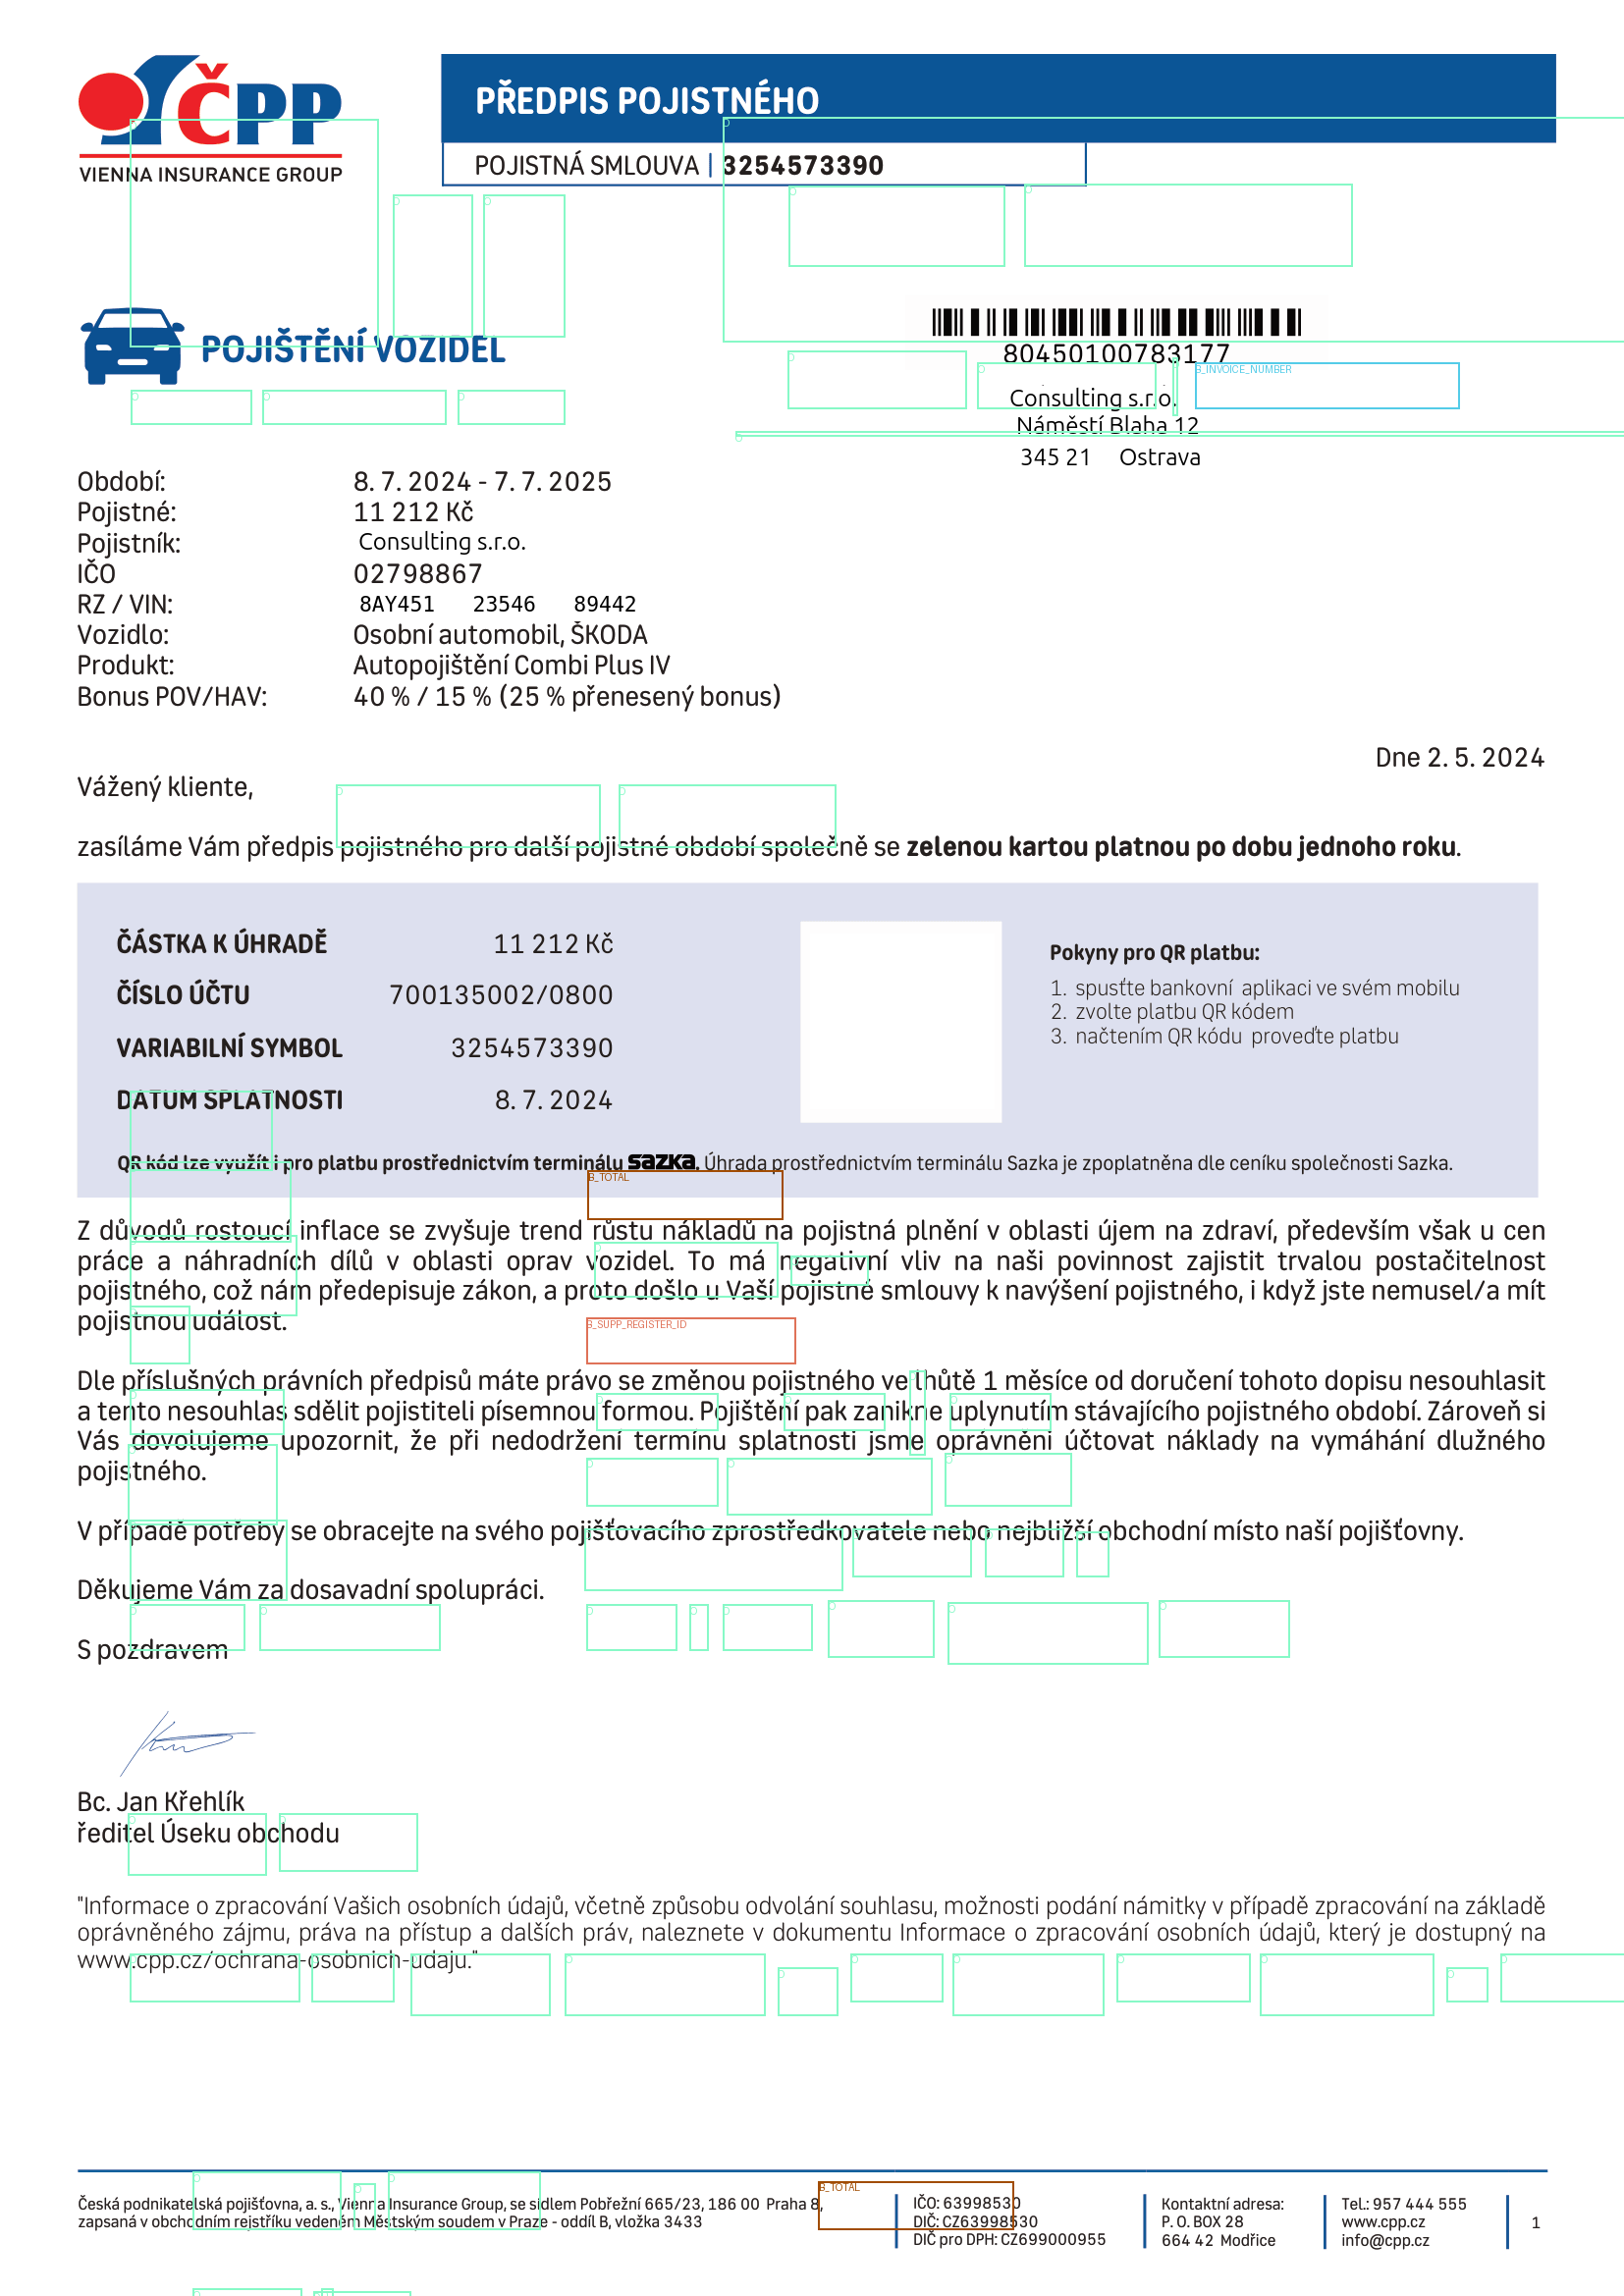

In [11]:
# We are visulizing boxes on original imag
for label_id, box in zip(ner_tags, boxes):
    x1, y1, x2, y2 = box
    box = [x1/1000 * image.width, y1/1000 * image.height, x2/1000 * image.width, y2/1000 * image.height]

    draw_1.rectangle(box, outline=label2color[id2label[label_id]], width=2)
    draw_1.text((box[0], box[1]), id2label[label_id], fill=label2color[id2label[label_id]], font=font, size=20)

image

# Collator funkce

In [12]:
import torch

def collate(batch):
  images = [item["image"].convert("RGB") for item in batch]
  tokens = [item["tokens"] for item in batch]
  boxes = [item["bboxes"] for item in batch]
  ner_tags = [item["ner_tags"] for item in batch]

  normalized_bboxes = []
  for item in boxes:
    W, H = images[0].size
    doc_boxes = []
    for box in item:
      # box = [x1, y1, x2, y2]
      normalized_box = [
        int(1000 * (box[0] / W)),
        int(1000 * (box[1] / H)),
        int(1000 * (box[2] / W)),
        int(1000 * (box[3] / H))
      ]
      # Ošetření clippingu (0-1000)
      normalized_box = [max(0, min(1000, c)) for c in normalized_box]
      doc_boxes.append(normalized_box)
    normalized_bboxes.append(doc_boxes)

  encoding = processor(images, tokens, boxes=normalized_bboxes,word_labels=ner_tags,
                         max_length=512, padding="max_length", stride=128, truncation=True,
                         return_overflowing_tokens=True, return_offsets_mapping =True,
                       return_tensors="pt")

  offset_mapping = encoding.pop('offset_mapping')

  overflow_to_sample_mapping = encoding.pop('overflow_to_sample_mapping')


  encoding["pixel_values"] = torch.stack(encoding["pixel_values"])
  return encoding

In [13]:
collate([train_dataset[0]])

{'input_ids': tensor([[    0,  1437,    36,  ...,  1717,   740,     2],
        [    0,   196,   282,  ..., 23119,  1140,     2],
        [    0,   858,    62,  ...,  3849, 10809,     2],
        [    0,   658,   282,  ...,     1,     1,     1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]]), 'bbox': tensor([[[  0,   0,   0,   0],
         [269,  21, 961,  63],
         [ 48,  22, 140,  64],
         ...,
         [912, 533, 919, 539],
         [926, 533, 951, 539],
         [  0,   0,   0,   0]],

        [[  0,   0,   0,   0],
         [235, 502, 325, 511],
         [235, 502, 325, 511],
         ...,
         [292, 661, 334, 670],
         [292, 661, 334, 670],
         [  0,   0,   0,   0]],

        [[  0,   0,   0,   0],
         [525, 609, 579, 618],
         [585, 609, 657, 621],
         ...,
         [224, 964, 267, 971],
         [224, 964, 267, 971],
         [  0, 

#Metriky

In [14]:
from evaluate import load
metric = load("seqeval")

In [15]:
import numpy as np

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Odstranění speciálních tokenů (-100 = ignore_id)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    return {
      "precision": results["overall_precision"],
      "recall": results["overall_recall"],
      "f1": results["overall_f1"],
      "accuracy": results["overall_accuracy"],
    }


# Training

In [16]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
                                    num_train_epochs=20,

                                    save_total_limit=2,
                                    output_dir=FINETUNED_MODEL_ID,
                                    per_device_train_batch_size=8,               # Batch size for training
                                    per_device_eval_batch_size=1,                # Batch size for evaluation
                                    learning_rate=1e-5,                          # Learning rate for the optimizer


                                    eval_strategy="epoch",
                                    save_strategy="epoch",

                                    load_best_model_at_end=True,                 # Load the best model when finished training
                                    metric_for_best_model="f1",            # Use accuracy as the metric to compare models
                                    greater_is_better = True,                     # Indicate whether the metric is to be maximized or minimized
                                    warmup_ratio=0.1, # we warmup a bit
                                    fp16=True, # we use mixed precision (less memory consumption)

                                    push_to_hub=True, # after training, we'd like to push our model to the hub
                                    hub_model_id=FINETUNED_MODEL_ID, # this is the name we'll use for our model on the hub,
                                    report_to="tensorboard",
                                    remove_unused_columns=False,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [17]:
from transformers.data.data_collator import default_data_collator

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate,
    compute_metrics=compute_metrics,
)

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.063833,0.812808,0.837563,0.825000,0.983444
2,No log,0.049388,0.866554,0.868020,0.867287,0.987368
3,No log,0.040022,0.887584,0.895093,0.891323,0.990506
4,No log,0.033820,0.904762,0.932318,0.918333,0.992625
5,No log,0.036192,0.902121,0.935702,0.918605,0.992389
6,No log,0.036495,0.914966,0.910321,0.912638,0.992232
7,No log,0.038181,0.902597,0.940778,0.921292,0.992311
8,No log,0.040441,0.900332,0.917090,0.908634,0.992232
9,No log,0.037452,0.912106,0.930626,0.921273,0.992468
10,No log,0.043886,0.911519,0.923858,0.917647,0.992075


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['layoutlmv3.embeddings.LayerNorm.weight', 'layoutlmv3.embeddings.LayerNorm.bias', 'layoutlmv3.LayerNorm.weight', 'layoutlmv3.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.0.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.0.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.1.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.1.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.attention.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.2.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.2.output.LayerNorm.bias', 'layoutlmv3.encoder.layer.3.attention.output.LayerNorm.weight', 'layoutlmv3.encoder.layer.3.attention.out

TrainOutput(global_step=460, training_loss=0.0249489514724068, metrics={'train_runtime': 428.0781, 'train_samples_per_second': 8.597, 'train_steps_per_second': 1.075, 'total_flos': 2129120236277760.0, 'train_loss': 0.0249489514724068, 'epoch': 20.0})

#Evaluace
Nutná pro automatické vytvoření huggingface model card na hubu

In [19]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_TOTAL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_VARIABLE_SYMBOL seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_REGISTER_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_SUPP_TAX_ID seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: B_ISSUE_DATE seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-pa

{'eval_loss': 0.04224259406328201,
 'eval_precision': 0.920265780730897,
 'eval_recall': 0.937394247038917,
 'eval_f1': 0.9287510477787092,
 'eval_accuracy': 0.9927814829344841,
 'eval_runtime': 2.7067,
 'eval_samples_per_second': 14.409,
 'eval_steps_per_second': 14.409,
 'epoch': 20.0}

# PUSH TO HUB

In [20]:
trainer.save_model(FINETUNED_MODEL_ID)
processor.save_pretrained(FINETUNED_MODEL_ID)

# Save processor and create model card
trainer.create_model_card()
trainer.push_to_hub()
processor.push_to_hub(repo_id=FINETUNED_MODEL_ID)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...123Test/training_args.bin: 100%|##########| 5.26kB / 5.26kB            

...

  ...0568.dbb2f2c3648e.20401.0: 100%|##########| 16.1kB / 16.1kB            

  ...123Test/model.safetensors:  74%|#######4  |  375MB /  504MB            

README.md: 0.00B [00:00, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/TomasFAV/Layoutlmv3InvoiceCzechV0123Test/commit/ec588d420759b47e014b302d8652ed1917815329', commit_message='Upload processor', commit_description='', oid='ec588d420759b47e014b302d8652ed1917815329', pr_url=None, repo_url=RepoUrl('https://huggingface.co/TomasFAV/Layoutlmv3InvoiceCzechV0123Test', endpoint='https://huggingface.co', repo_type='model', repo_id='TomasFAV/Layoutlmv3InvoiceCzechV0123Test'), pr_revision=None, pr_num=None)

# Interference

In [21]:
!apt-get install tesseract-ocr-ces
!pip install -q pytesseract

Reading package lists... Done
^C


In [22]:
from transformers import AutoProcessor
from transformers import LayoutLMv3ForTokenClassification

processor = AutoProcessor.from_pretrained(FINETUNED_MODEL_ID, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(FINETUNED_MODEL_ID)

Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

In [23]:
id2label = model.config.id2label

In [24]:
from PIL import Image
import pytesseract

def get_ocr_data_for_layoutlm(image: Image.Image, lang: str = "ces"):
    """
    Provede OCR a vrátí data připravená pro processor.feature_extractor (LayoutLMv3).
    """
    ocr_df = pytesseract.image_to_data(image, lang=lang, output_type=pytesseract.Output.DICT)

    words = []
    boxes = []
    width, height = image.size

    for i in range(len(ocr_df["text"])):
        # Filtrujeme prázdné řetězce a whitespace
        word = ocr_df["text"][i].strip()
        if word != "":
            words.append(word)

            # Tesseract dává: left, top, width, height
            x, y, w, h = ocr_df["left"][i], ocr_df["top"][i], ocr_df["width"][i], ocr_df["height"][i]

            # Normalizace na rozsah 0-1000 pro LayoutLMv3
            # x1, y1 (vlevo nahoře), x2, y2 (vpravo dole)
            normalized_box = [
                int(1000 * (x / width)),
                int(1000 * (y / height)),
                int(1000 * ((x + w) / width)),
                int(1000 * ((y + h) / height))
            ]
            boxes.append(normalized_box)

    return words, boxes

In [25]:
from PIL import Image
img = Image.open("/content/2dc47732-1.png").convert("RGB").resize((1654,2338))
img

FileNotFoundError: [Errno 2] No such file or directory: '/content/2dc47732-1.png'

In [ ]:


words, boxes = get_ocr_data_for_layoutlm(img)

encoding = processor(
            img,
            text=words,
            boxes=boxes,
            return_tensors="pt",
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            max_length=512,
            stride=128,
            padding="max_length",
            truncation=True
        )

offset_mapping = encoding.pop('offset_mapping')

overflow_to_sample_mapping = encoding.pop('overflow_to_sample_mapping')

encoding["pixel_values"] = torch.stack(encoding["pixel_values"])

for k,v in encoding.items():
  print(k,v.shape)
  encoding[k] = v.to(device)

In [ ]:
model.to(device)
outputs = model(**encoding)

In [ ]:
logits = outputs.logits
predictions = logits.view(1, -1, logits.size(2)).squeeze(0).argmax(-1)
predictions.shape

In [ ]:
bbox = encoding.bbox
bbox = bbox.view(1, -1, bbox.size(2)).squeeze(0)
bbox.shape

In [ ]:
def unnormalize_box(bbox, width, height):
     return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]

predictions = predictions
token_boxes = bbox.tolist()

width, height = img.size

In [ ]:
offset_mapping.view(1, -1, offset_mapping.size(2)).squeeze(0).shape

In [ ]:
import numpy as np

is_subword = np.array(offset_mapping.view(1, -1, offset_mapping.size(2)).squeeze(0).tolist())[:,0] != 0


true_predictions = [id2label[pred.item()] for idx, pred in enumerate(predictions) if not is_subword[idx]]
true_boxes = [unnormalize_box(box, width, height) for idx, box in enumerate(token_boxes) if not is_subword[idx]]

In [ ]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(img)

font = ImageFont.load_default()

def iob_to_label(label):
    label = label[2:]
    if not label:
      return 'other'
    return label

for prediction, box in zip(true_predictions, true_boxes):
    predicted_label = iob_to_label(prediction).lower()
    draw.rectangle(box, outline="red")
    draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill="blue", font=font)

img

In [ ]:
image.save("faktura.jpg")